In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import math


def save_fig(name):
    plt.savefig(os.path.join("../Data", name), dpi=300, bbox_inches='tight')


name = 'sar_3.jpg'
image = cv2.imread(name)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# 1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)

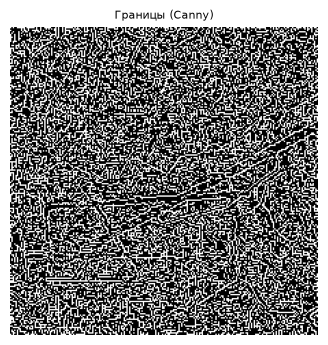

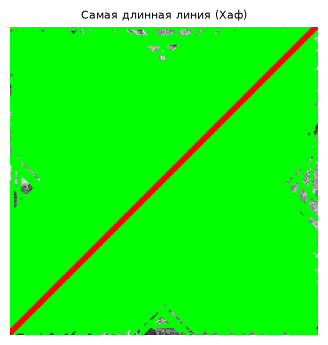

In [8]:
# Детектор границ
edges = cv2.Canny(image_gray, 50, 150)

plt.figure(figsize=(5, 4))
plt.title("Границы (Canny)", fontsize=8)
plt.imshow(edges, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.axis('off')
save_fig("Canny.png")

# Преобразование Хафа (отрезки)
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=40,
    maxLineGap=20
)

line_img = image.copy()

longest = None
max_len = 0

# Поиск самой длинной линии
for line in lines:
    x1, y1, x2, y2 = np.array(line).reshape(4)
    length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    if length > max_len:
        max_len = length
        longest = (x1, y1, x2, y2)

for line in lines:
    x1, y1, x2, y2 = np.array(line).reshape(4)
    cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

if longest is not None:
    x1, y1, x2, y2 = longest
    cv2.line(line_img, (x1, y1), (x2, y2), (0, 0, 255), 3)

plt.figure(figsize=(5, 4))
plt.title("Самая длинная линия (Хаф)", fontsize=8)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.xticks([])
plt.yticks([])
plt.axis('off')
save_fig("LongestLine.png")


# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

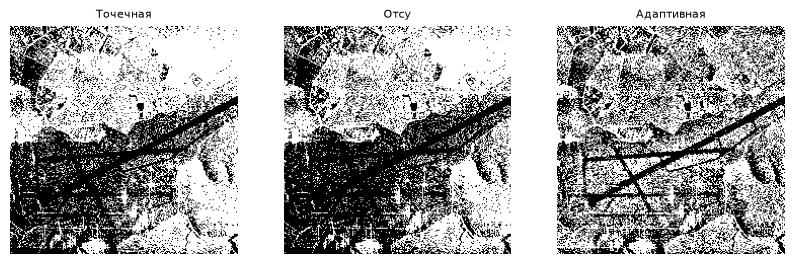

In [9]:
# Точечная
_, th_simple = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY)

# Отсу
_, th_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Адаптивная бинаризация
th_adapt = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    35,
    5
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Точечная", fontsize=8)
plt.imshow(th_simple, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Отсу", fontsize=8)
plt.imshow(th_otsu, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Адаптивная", fontsize=8)
plt.imshow(th_adapt, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.axis('off')

save_fig("Binarization.png")

plt.show()